# Лабораторная работа 3. Классификация. Нейронные сети

## Описание работы

**Цель работы:** изучение методов классификации данных, реализованные в библиотеке Scikit-Learn, а также ознакомление с нейронными сетями с использованием библиотек TensorFlow и TensorBoard.

**Постановка задачи:**

1. Необходимо выбрать и подготовить датасет для классификации, затем построить классификационные модели с помощью пяти методов:

    - Наивный Байесовский классификатор (GaussianNB, MultinomialNB, ComplementNB, BernoulliNB);

    - Деревья решений (Decision Tree);

    - Линейный дискриминантный анализ (Linear Discriminant Analysis);

    - Метод опорных векторов (Support Vector Machines);

    - Метод ближайших соседей (k-Nearest Neighbors);

2. Затем сравните качество работы классификаторов с помощью следующих метрик:

    - Accuracy (точность),

    - Precision (доля правильно классифицированных положительных примеров),

    - Recall (чувствительность, доля верно найденных положительных примеров),

    - F1-Score (среднее гармоническое precision и recall),

    - Площадь под кривой ROC (AUC-ROC).

3. Настройте гиперпараметры каждого метода и проведите исследование влияния различных параметров на качество классификации.

4. Реализуйте и протестируйте нейронную сеть на TensorFlow, исследуйте эффект настройки гиперпараметров и визуализируйте процесс обучения с помощью инструмента TensorBoard.

## Ход работы

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv('datasets/Titanic-Dataset.csv')

data.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


array([[<Axes: title={'center': 'PassengerId'}>,
        <Axes: title={'center': 'Survived'}>,
        <Axes: title={'center': 'Pclass'}>],
       [<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'SibSp'}>,
        <Axes: title={'center': 'Parch'}>],
       [<Axes: title={'center': 'Fare'}>, <Axes: >, <Axes: >]],
      dtype=object)

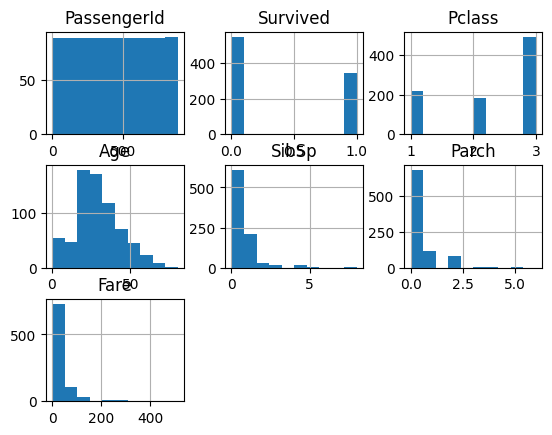

In [2]:
data.info()

data.hist()

In [3]:
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [4]:
data.drop(labels='Cabin', inplace=True, axis=1)
data.drop(labels='Name', inplace=True, axis=1)
data.drop(labels='Ticket', inplace=True, axis=1)
data.drop(labels='PassengerId', inplace=True, axis=1)
data['Age'] = data['Age'].fillna(data['Age'].median())

data['Embarked'] = data['Embarked'].fillna('S')



data.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [5]:
data.Embarked.value_counts()


Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

array([[<Axes: title={'center': 'Survived'}>,
        <Axes: title={'center': 'Pclass'}>],
       [<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'SibSp'}>],
       [<Axes: title={'center': 'Parch'}>,
        <Axes: title={'center': 'Fare'}>]], dtype=object)

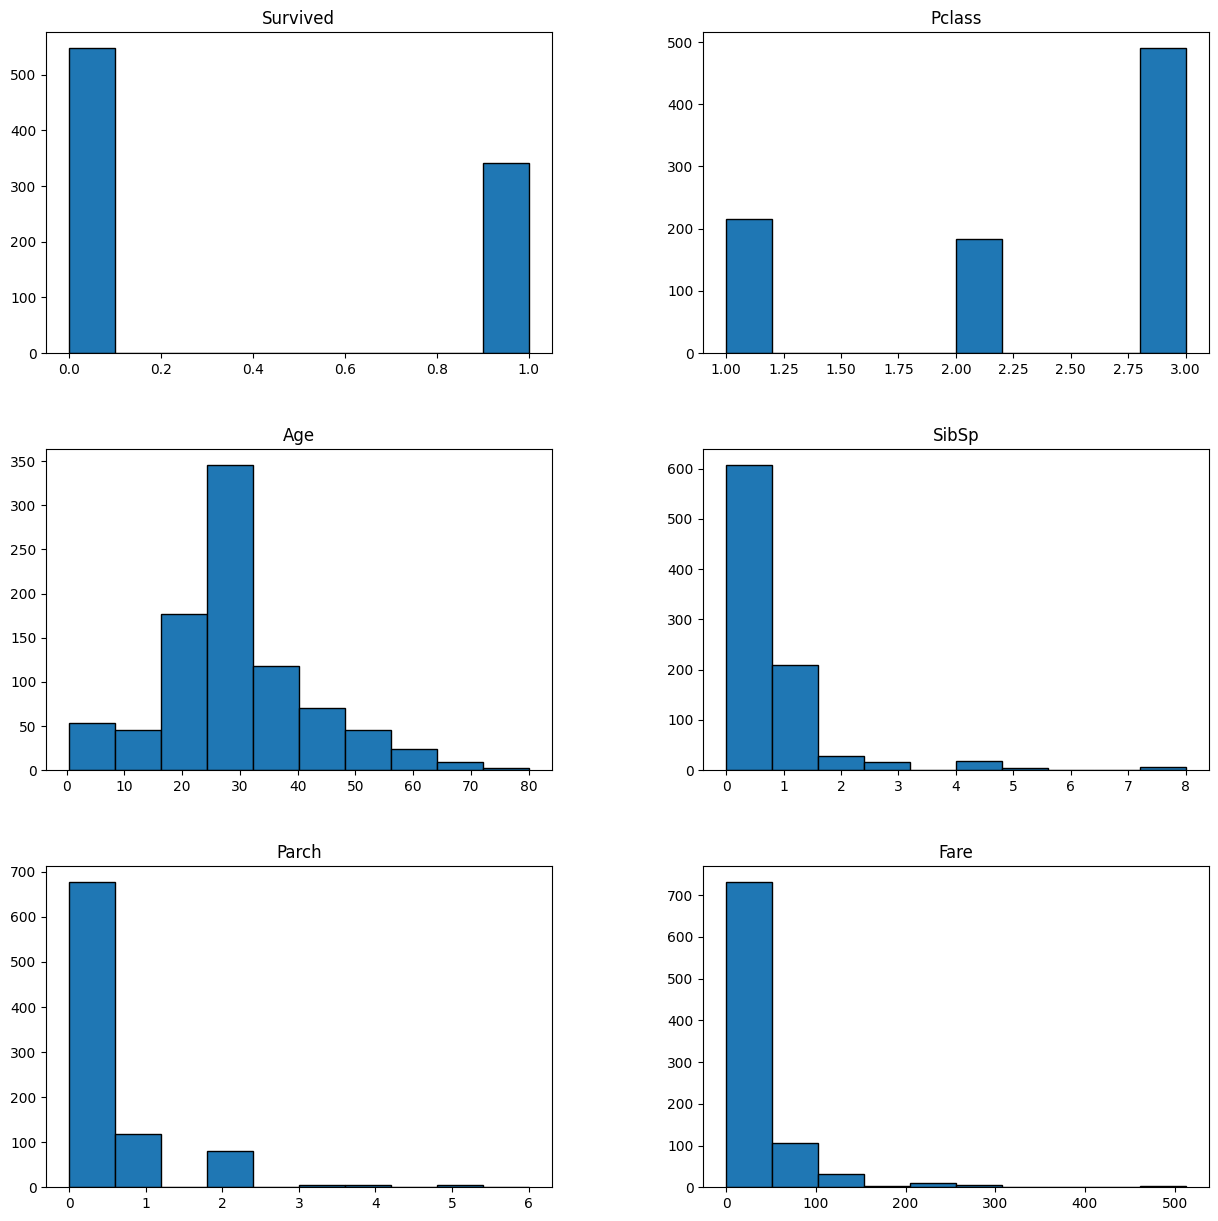

In [6]:
data.hist(edgecolor='black',  figsize=(15, 15), grid=False)

Text(0.5, 1.0, 'Embarked')

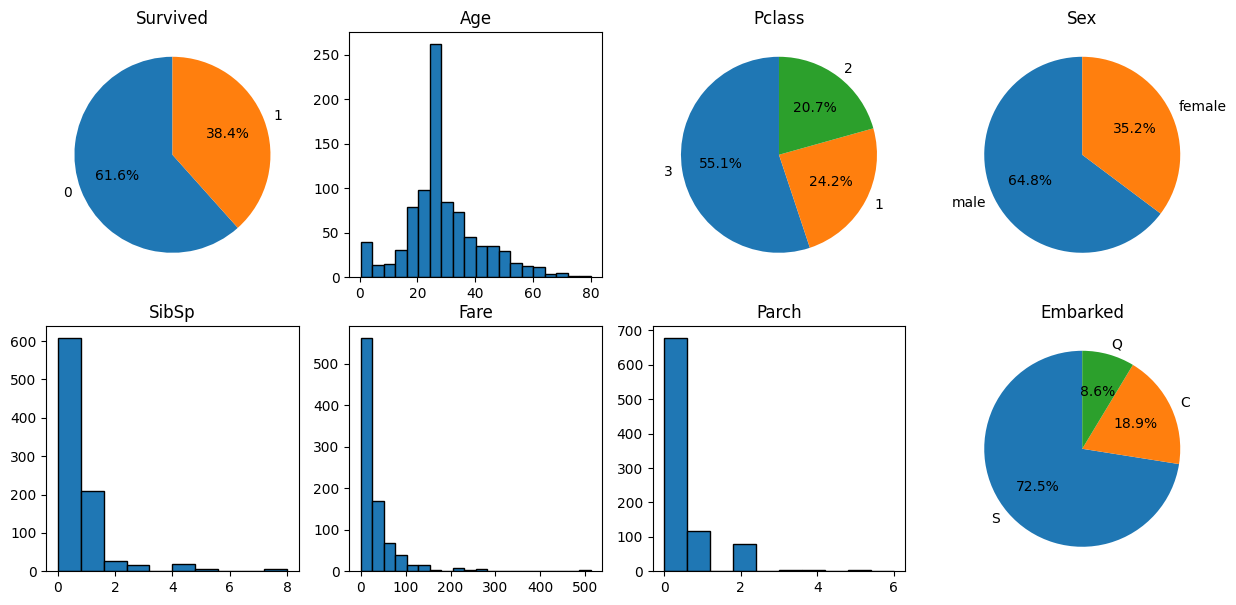

In [7]:
fig, ax = plt.subplots(nrows = 2, ncols = 4, figsize = (15,7))

ax[0,0].pie(data.Survived.value_counts(), labels= data.Survived.value_counts().index, autopct='%1.1f%%', startangle=90)
ax[0,0].set_title('Survived')


ax[0, 1].hist(data.Age, bins=20, edgecolor='black')
ax[0, 1].set_title('Age')

ax[0,2].pie(data.Pclass.value_counts(), labels= data.Pclass.value_counts().index, autopct='%1.1f%%', startangle=90)
ax[0, 2].set_title('Pclass')

ax[0,3].pie(data.Sex.value_counts(), labels= data.Sex.value_counts().index, autopct='%1.1f%%', startangle=90)
ax[0, 3].set_title('Sex')

ax[1,0].hist(data.SibSp, edgecolor='black')
ax[1, 0].set_title('SibSp')

ax[1, 1].hist(data.Fare, bins=20, edgecolor='black')
ax[1, 1].set_title('Fare')

ax[1,2].hist(data.Parch, edgecolor='black')
ax[1, 2].set_title('Parch')

ax[1,3].pie(data.Embarked.value_counts(), labels= data.Embarked.value_counts().index, autopct='%1.1f%%', startangle=90)
ax[1, 3].set_title('Embarked')

In [8]:
data['Embarked'] = data['Embarked'].fillna('Missing')
data = pd.get_dummies(data, columns=['Embarked'], drop_first=False, dtype='int8')
map_sex = {'male':1, 'female':0}

data['Sex'] = data['Sex'].map(map_sex)

In [9]:
data.describe()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,0.647587,29.361582,0.523008,0.381594,32.204208,0.188552,0.086420,0.725028
std,0.486592,0.836071,0.477990,13.019697,1.102743,0.806057,49.693429,0.391372,0.281141,0.446751
min,0.000000,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,0.000000,22.000000,0.000000,0.000000,7.910400,0.000000,0.000000,0.000000
50%,0.000000,3.000000,1.000000,28.000000,0.000000,0.000000,14.454200,0.000000,0.000000,1.000000
75%,1.000000,3.000000,1.000000,35.000000,1.000000,0.000000,31.000000,0.000000,0.000000,1.000000
max,1.000000,3.000000,1.000000,80.000000,8.000000,6.000000,512.329200,1.000000,1.000000,1.000000


In [10]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

data_scaled = pd.DataFrame(scaler.fit_transform(data),columns=data.columns)

data_scaled

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,-0.789272,0.827377,0.737695,-0.565736,0.432793,-0.473674,-0.502445,-0.482043,-0.307562,0.615838
1,1.266990,-1.566107,-1.355574,0.663861,0.432793,-0.473674,0.786845,2.074505,-0.307562,-1.623803
2,1.266990,0.827377,-1.355574,-0.258337,-0.474545,-0.473674,-0.488854,-0.482043,-0.307562,0.615838
3,1.266990,-1.566107,-1.355574,0.433312,0.432793,-0.473674,0.420730,-0.482043,-0.307562,0.615838
4,-0.789272,0.827377,0.737695,0.433312,-0.474545,-0.473674,-0.486337,-0.482043,-0.307562,0.615838
...,...,...,...,...,...,...,...,...,...,...
886,-0.789272,-0.369365,0.737695,-0.181487,-0.474545,-0.473674,-0.386671,-0.482043,-0.307562,0.615838
887,1.266990,-1.566107,-1.355574,-0.796286,-0.474545,-0.473674,-0.044381,-0.482043,-0.307562,0.615838
888,-0.789272,0.827377,-1.355574,-0.104637,0.432793,2.008933,-0.176263,-0.482043,-0.307562,0.615838
889,1.266990,-1.566107,0.737695,-0.258337,-0.474545,-0.473674,-0.044381,2.074505,-0.307562,-1.623803


In [11]:
from sklearn.model_selection import train_test_split

X = data[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_C', 'Embarked_Q', 'Embarked_S']]

y = data['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)


### Наивный Байесовский классификатор (GaussianNB, MultinomialNB, ComplementNB, BernoulliNB)

In [12]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

model_nb = GaussianNB()

model_nb.fit(X_train, y_train)

y_predNB = model_nb.predict(X_test)


print(confusion_matrix(y_test, y_predNB))
accuracyNB = accuracy_score(y_test, y_predNB)
recallNB = recall_score(y_test, y_predNB)
precisionNB = precision_score(y_test, y_predNB)
f1NB = f1_score(y_test, y_predNB)
roc_aucNB = roc_auc_score(y_test, y_predNB)
accuracyNB



[[141  34]
 [ 29  91]]


0.7864406779661017

### Деревья решений (Decision Tree)

[[157  18]
 [ 35  85]]


0.8203389830508474

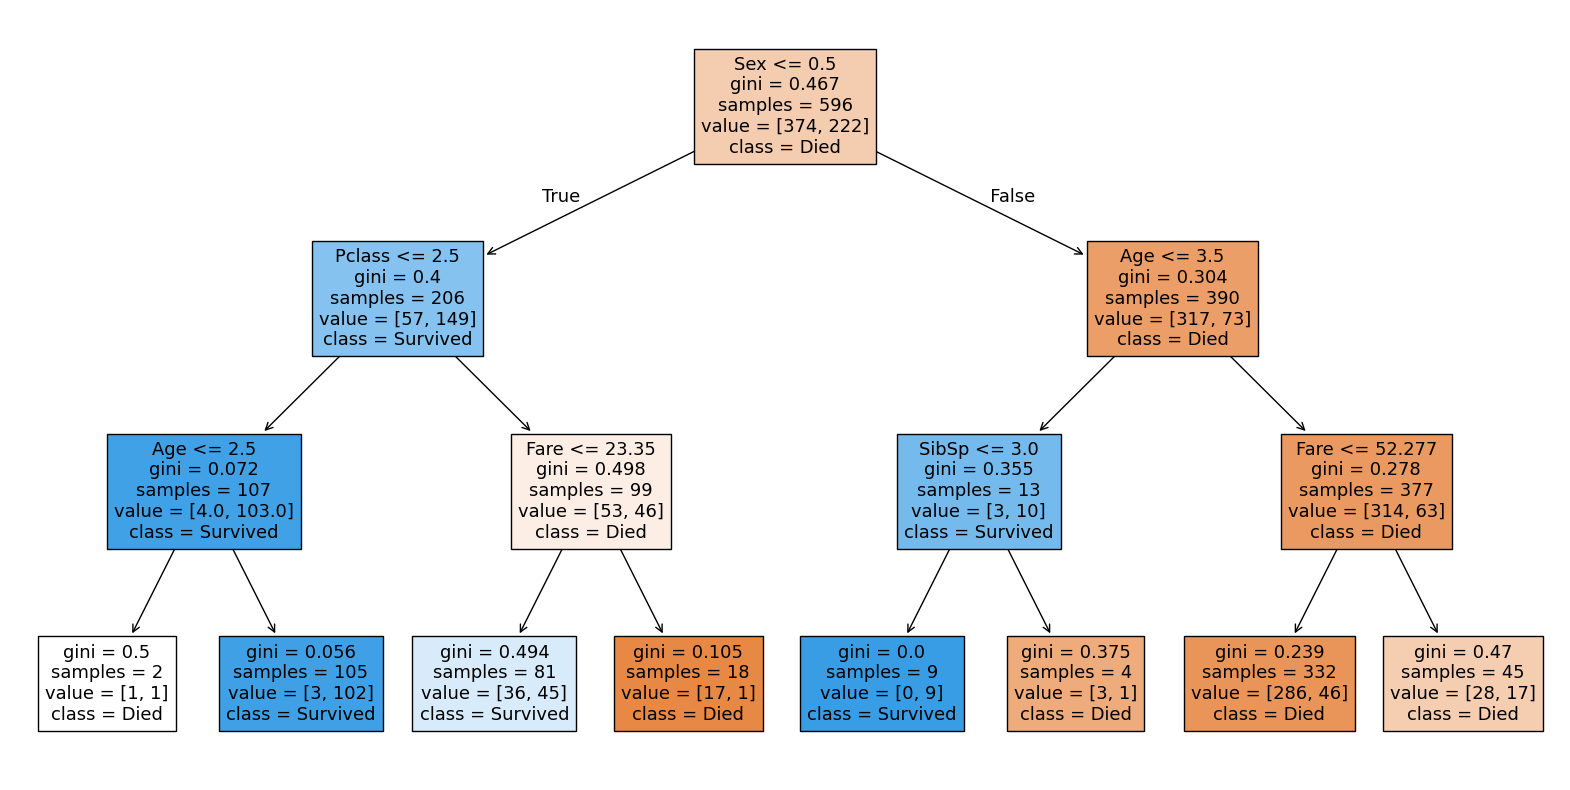

In [13]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

model_tree = DecisionTreeClassifier(
    max_depth=3
)

model_tree.fit(X_train, y_train)

y_predTree = model_tree.predict(X_test)

print(confusion_matrix(y_test, y_predTree))
accuracyTree = accuracy_score(y_test, y_predTree)
recallTree = recall_score(y_test, y_predTree)
precisionTree = precision_score(y_test, y_predTree)
f1Tree = f1_score(y_test, y_predTree)
roc_aucTree = roc_auc_score(y_test, y_predTree)

plt.figure(figsize=(20,10))
plot_tree(model_tree,
    filled=True,
    feature_names=X.columns,
    class_names=['Died', 'Survived']
    )
accuracyTree

### Линейный дискриминантный анализ (Linear Discriminant Analysis)


In [19]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

model_LDA = LinearDiscriminantAnalysis(solver='eigen')

model_LDA.fit(X_test, y_test)

y_predLDA = model_LDA.predict(X_test)

print(confusion_matrix(y_test, y_predLDA))

accuracyLDA = accuracy_score(y_test, y_predLDA)
recallLDA = recall_score(y_test, y_predLDA)
precisionLDA = precision_score(y_test, y_predLDA)
f1LDA = f1_score(y_test, y_predLDA)
roc_aucLDA = roc_auc_score(y_test, y_predLDA)

accuracyLDA

[[152  23]
 [ 27  93]]


0.8305084745762712

### Метод опорных векторов (Support Vector Machines)

### Метод ближайших соседей (k-Nearest Neighbors)